# Compare full and reduced model for different parameter ranges

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import gsc_model_functions as gmf

In [2]:
# parameters that will remain the same for both full and reeduced models
t_end = 20000 # days
dt = 0.1 # days
t = np.arange(0, t_end+dt, dt)

n = 10 # num of compartments
ms = 0.2 # 1/days
delta_s = 0.001 # 1/days
Ps = 0.52
# assume perfectly hierchcical CSC division
r = np.zeros(n)
r[0] = 1

k = 1 # carrying capacity

# IC start with small fraction of CSCs
IC = 0.1
u0 = np.zeros(n+1)
u0[0] = IC

u0_reduced = np.array([IC, 0]) # start with same number of CSCs, and no differentiated cells

In [3]:
# =======================
# First: Vary m_v with fixed delta_v
# =======================

m_v_vals = np.array([0.1, 0.5, 1])
delta_v_fixed = 0.05

u_save_full_mv = np.zeros((len(t), n+1, len(m_v_vals)))
u_save_reduced_mv = np.zeros((len(t), 2, len(m_v_vals)))
vi_reconstructed_mv = np.zeros((len(t), n, len(m_v_vals)))
u_reconstructed_mv = np.zeros((len(t), n+1, len(m_v_vals)))

# Simulate
for i in range(len(m_v_vals)):
    mv = m_v_vals[i] * np.ones(n)
    mv[-1] = 0
    delta_v = delta_v_fixed * np.ones(n)
    
    t_full, u_full = gmf.simulate_simple(t_end, dt, u0, n, Ps, k, ms, mv, delta_s, delta_v, r)
    u_save_full_mv[:,:,i] = u_full
    
    t_red, u_red = gmf.simulate_simple_reduced(t_end, dt, u0_reduced, n, Ps, k, ms, mv, delta_s, delta_v, r)
    u_save_reduced_mv[:,:,i] = u_red

# Reconstruct
for i in range(len(m_v_vals)):
    mv = m_v_vals[i] * np.ones(n)
    mv[-1] = 0
    delta_v = delta_v_fixed * np.ones(n)
    
    VS_reduced = u_save_reduced_mv[:,:,i]
    N_reduced = np.sum(u_save_reduced_mv[:,:,i], axis=1)
    
    u_reconstructed_mv[:,0,i] = VS_reduced[:,0]
    vi_reconstructed_mv[:,0,i] = gmf.alpha_1(N_reduced, mv, k, delta_v, n) * VS_reduced[:,1]
    
    for j in range(1, n):
        vi_reconstructed_mv[:,j,i] = gmf.alpha_i(N_reduced, mv, k, delta_v, j) * vi_reconstructed_mv[:,j-1,i]
    
    u_reconstructed_mv[:,1:,i] = vi_reconstructed_mv[:,:,i]


In [4]:
# =======================
# Part 2: Vary delta_v with fixed m_v
# =======================

delta_v_vals = np.array([0.01, 0.05, 0.2])
m_v_fixed = 0.4

u_save_full_dv = np.zeros((len(t), n+1, len(delta_v_vals)))
u_save_reduced_dv = np.zeros((len(t), 2, len(delta_v_vals)))
vi_reconstructed_dv = np.zeros((len(t), n, len(delta_v_vals)))
u_reconstructed_dv = np.zeros((len(t), n+1, len(delta_v_vals)))

# Simulate
for i in range(len(delta_v_vals)):
    mv = m_v_fixed * np.ones(n)
    mv[-1] = 0
    delta_v = delta_v_vals[i] * np.ones(n)
    
    t_full, u_full = gmf.simulate_simple(t_end, dt, u0, n, Ps, k, ms, mv, delta_s, delta_v, r)
    u_save_full_dv[:,:,i] = u_full
    
    t_red, u_red = gmf.simulate_simple_reduced(t_end, dt, u0_reduced, n, Ps, k, ms, mv, delta_s, delta_v, r)
    u_save_reduced_dv[:,:,i] = u_red

# Reconstruct
for i in range(len(delta_v_vals)):
    mv = m_v_fixed * np.ones(n)
    mv[-1] = 0
    delta_v = delta_v_vals[i] * np.ones(n)
    
    VS_reduced = u_save_reduced_dv[:,:,i]
    N_reduced = np.sum(u_save_reduced_dv[:,:,i], axis=1)
    
    u_reconstructed_dv[:,0,i] = VS_reduced[:,0]
    vi_reconstructed_dv[:,0,i] = gmf.alpha_1(N_reduced, mv, k, delta_v, n) * VS_reduced[:,1]
    
    for j in range(1, n):
        vi_reconstructed_dv[:,j,i] = gmf.alpha_i(N_reduced, mv, k, delta_v, j) * vi_reconstructed_dv[:,j-1,i]
    
    u_reconstructed_dv[:,1:,i] = vi_reconstructed_dv[:,:,i]

In [5]:
# Colors from red to green
cmap = plt.get_cmap('RdYlGn')
# Interpolated colors at these positions
col = [cmap(p) for p in np.linspace(0, 1, n+1)]

def plot_comparison(t,u_recon, u_full,ax):

    for i in range(u_recon.shape[1]):
        ax.plot(t, u_recon[:,i], linestyle='dashed', color=col[i])
        ax.plot(t, u_full[:,i], color=col[i])
    
    # we could plot total tumour size but I think this makes it hared to compare the compartments
    ax.plot(t, np.sum(u_recon, axis=1), linestyle='dashed', color='black', label='Reduced')
    ax.plot(t, np.sum(u_full, axis=1), color='black', label='Full')


def plot_zoom(t,u_recon, u_full,ax, t_ind = 2000):
        
    for i in range(u_recon.shape[1]):
        ax.plot(t[0:t_ind], u_recon[0:t_ind,i], linestyle='dashed', color=col[i])
        ax.plot(t[0:t_ind], u_full[0:t_ind,i], color=col[i])

def plot_com_frac(t, u_red, u_full, ax):
    u_red_fract = u_red/np.sum(u_red, axis=1)[:, None]
    u_full_fract = u_full/np.sum(u_full, axis=1)[:, None]

    for i in range(u_red_fract.shape[1]):
        ax.plot(t, u_red_fract[:,i], linestyle='dashed', color=col[i])
        ax.plot(t, u_full_fract[:,i], color=col[i])

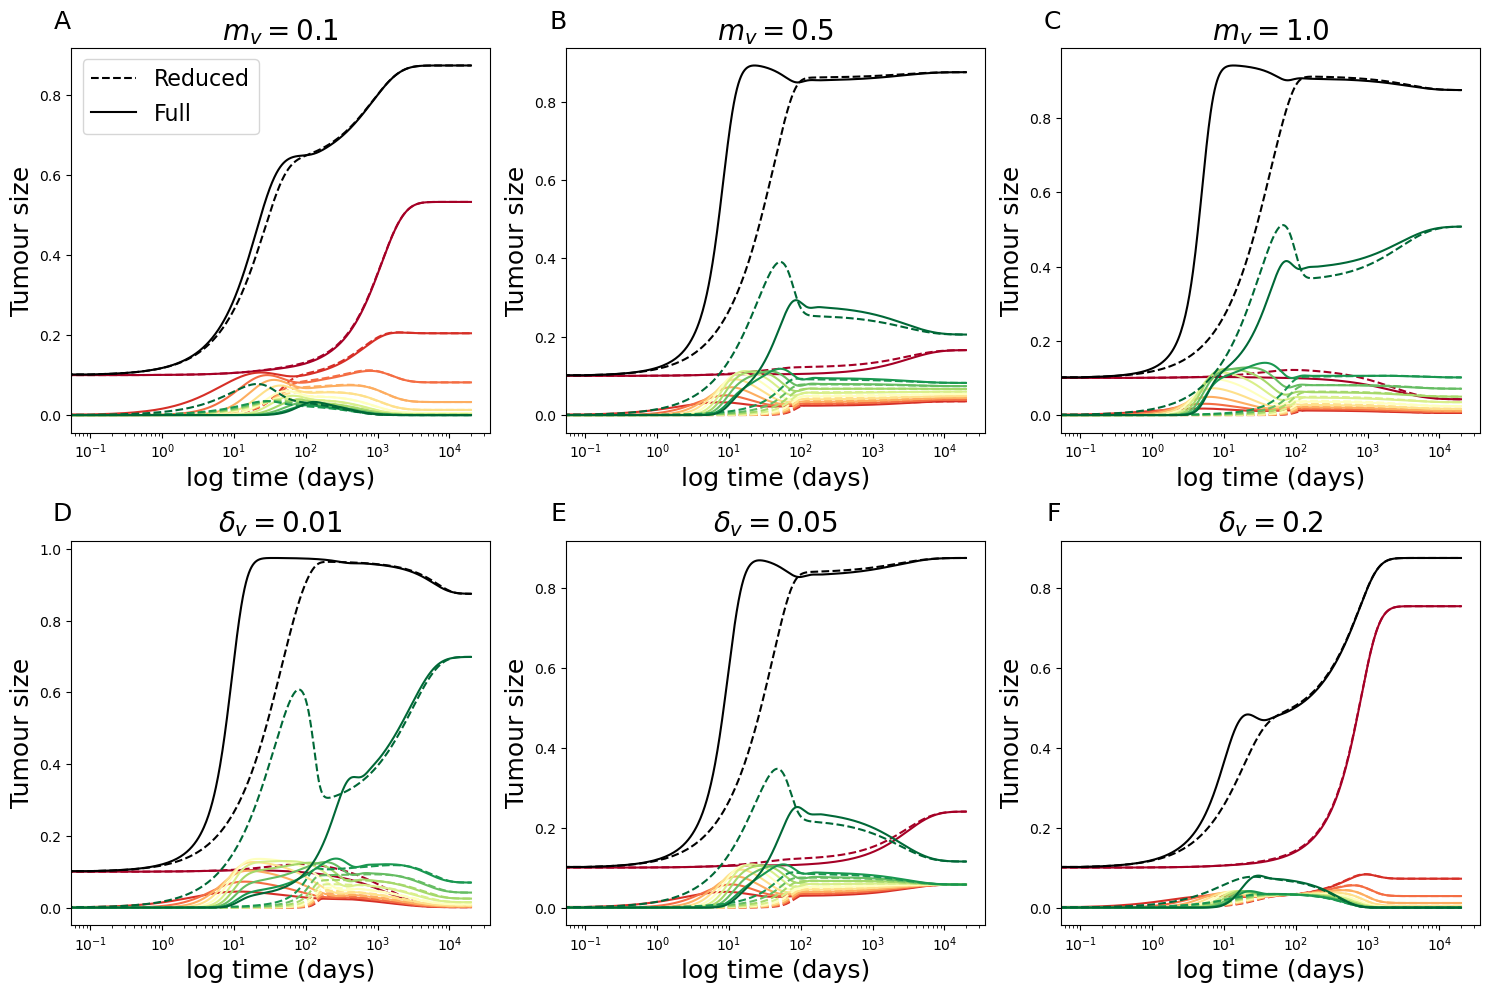

In [6]:
fig, ax = plt.subplots(2,3, figsize=(15,10))
ax = ax.flatten()

counter = 0
count_frac = 0

for i in range(3):


    # plot raw tumour size
    plot_comparison(t, u_reconstructed_mv[:,:,counter], u_save_full_mv[:,:,counter],ax[i])
    counter = counter + 1
    ax[i].set_xscale('log')
    #ax[i].set_yscale('log')
    ax[i].set_title(f'$m_v = {m_v_vals[i]}$', fontsize =20)

for i in range(3,6):

    # plot tumour size fractions
    plot_comparison(t, u_reconstructed_dv[:,:,count_frac], u_save_full_dv[:,:,count_frac], ax[i])
    count_frac = count_frac + 1
    ax[i].set_xscale('log')
    ax[i].set_title(f'$\\delta_v = {delta_v_vals[i-3]}$', fontsize =20)


# add axes labels and A, B, C ... labels
for i in range(len(ax)):
    ax[i].set_xlabel('log time (days)', fontsize = 18)
    ax[i].set_ylabel('Tumour size', fontsize = 18)
    ax[i].text(0, 1.1, chr(65+i), transform=ax[i].transAxes, fontsize=18, va='top', ha='right')

ax[0].legend(fontsize=16, loc  = 'upper left')


plt.tight_layout()
plt.savefig('Figs/Full_red_comparison.pdf', bbox_inches='tight')
plt.show()

# Different PC components - reduced model from full model

In [7]:
# look at the effect of different initial compositions on the model comparison.
# think of this as the opposite of what we just did, where we compred a recnostructed full model from a reduced model simulation.
# here we will simulate the full model with different initial compositions, and then construct the reduced model by adding all the compartments up.

t_end = 20000 # days
dt = 0.1 # days
t = np.arange(0, t_end+dt, dt)


delta_v = 0.05 * np.ones(n)

gsc_ic = 0.001
pc_ic = 0.1

# composition 1 all PCs in comaprtment 1
u0_all_v1 = np.zeros(n+1)
u0_all_v1[0] = gsc_ic
u0_all_v1[1] = pc_ic

# composition 2 all PCs in final compartment
u0_all_vn = np.zeros(n+1)
u0_all_vn[0] = gsc_ic
u0_all_vn[-1] = pc_ic

# composition 3 equal number of PCs in each compartment
u0_equal = np.zeros(n+1)
u0_equal[0] = gsc_ic
u0_equal[1:] = pc_ic/n

# reduced ICs are the same for all 3 compositions, as they only have 2 compartments
u0_reduced = np.array([gsc_ic, pc_ic])

u_full_all_v1_save = np.zeros((len(t),n+1,len(m_v_vals)))
u_full_all_vn_save = np.zeros((len(t),n+1,len(m_v_vals)))
u_full_equal_save = np.zeros((len(t),n+1,len(m_v_vals)))

u_full_red_v1_save = np.zeros((len(t),2,len(m_v_vals)))
u_full_red_vn_save = np.zeros((len(t),2,len(m_v_vals)))
u_full_red_equal_save = np.zeros((len(t),2,len(m_v_vals)))

u_red_save = np.zeros((len(t),2,len(m_v_vals)))


for i in range(len(m_v_vals)):

    mv = m_v_vals[i]*np.ones(n)
    mv[-1] = 0 # last compartment has no differentiation, so mv=0

    # sim full model
    t_full,u1_full = gmf.simulate_simple(t_end,dt,u0_all_v1,n,Ps,k,ms,mv,delta_s,delta_v,r)
    t_full,un_full = gmf.simulate_simple(t_end,dt,u0_all_vn,n,Ps,k,ms,mv,delta_s,delta_v,r)
    t_full,uequal_full = gmf.simulate_simple(t_end,dt,u0_equal,n,Ps,k,ms,mv,delta_s,delta_v,r)

    u_full_all_v1_save[:,:,i] = u1_full
    u_full_all_vn_save[:,:,i] = un_full
    u_full_equal_save[:,:,i] = uequal_full

    u_full_red_v1_save[:,:,i] = np.array([u1_full[:,0], np.sum(u1_full[:,1:], axis=1)]).T
    u_full_red_vn_save[:,:,i] = np.array([un_full[:,0], np.sum(un_full[:,1:], axis=1)]).T
    u_full_red_equal_save[:,:,i] = np.array([uequal_full[:,0], np.sum(uequal_full[:,1:], axis=1)]).T

    # simulate reduced model
    t_red, u1_red = gmf.simulate_simple_reduced(t_end,dt,u0_reduced,n,Ps,k,ms,mv,delta_s,delta_v,r)
    u_red_save[:,:,i] = u1_red



In [8]:
def plot_V(t,u_recon, u_full,ax,col = 'k'):

    # plot the CSC comaprtment
    #ax.plot(t, u_recon[:,0], color='red')
    #ax.plot(t, u_full[:,0], color='red')

    #for i in range(1, u_recon.shape[1]):
    # 0 compaonent is CSCs, 1 componet is PCs
    #ax.plot(t, u_recon[:,1], linestyle='dashed', color='blue')
    ax.plot(t, u_full[:,1], color=col)
        #ax.plot(t, np.sum(u_full[:,i],axis=1), color='black', label='Total (full)')

    # we could plot total tumour size but I think this makes it hared to compare the compartments
    #ax.plot(t, np.sum(u_recon, axis=1), linestyle='dashed', color='black', label='Total (reduced)')
    #ax.plot(t, np.sum(u_full, axis=1), color='black', label='Total (full)')




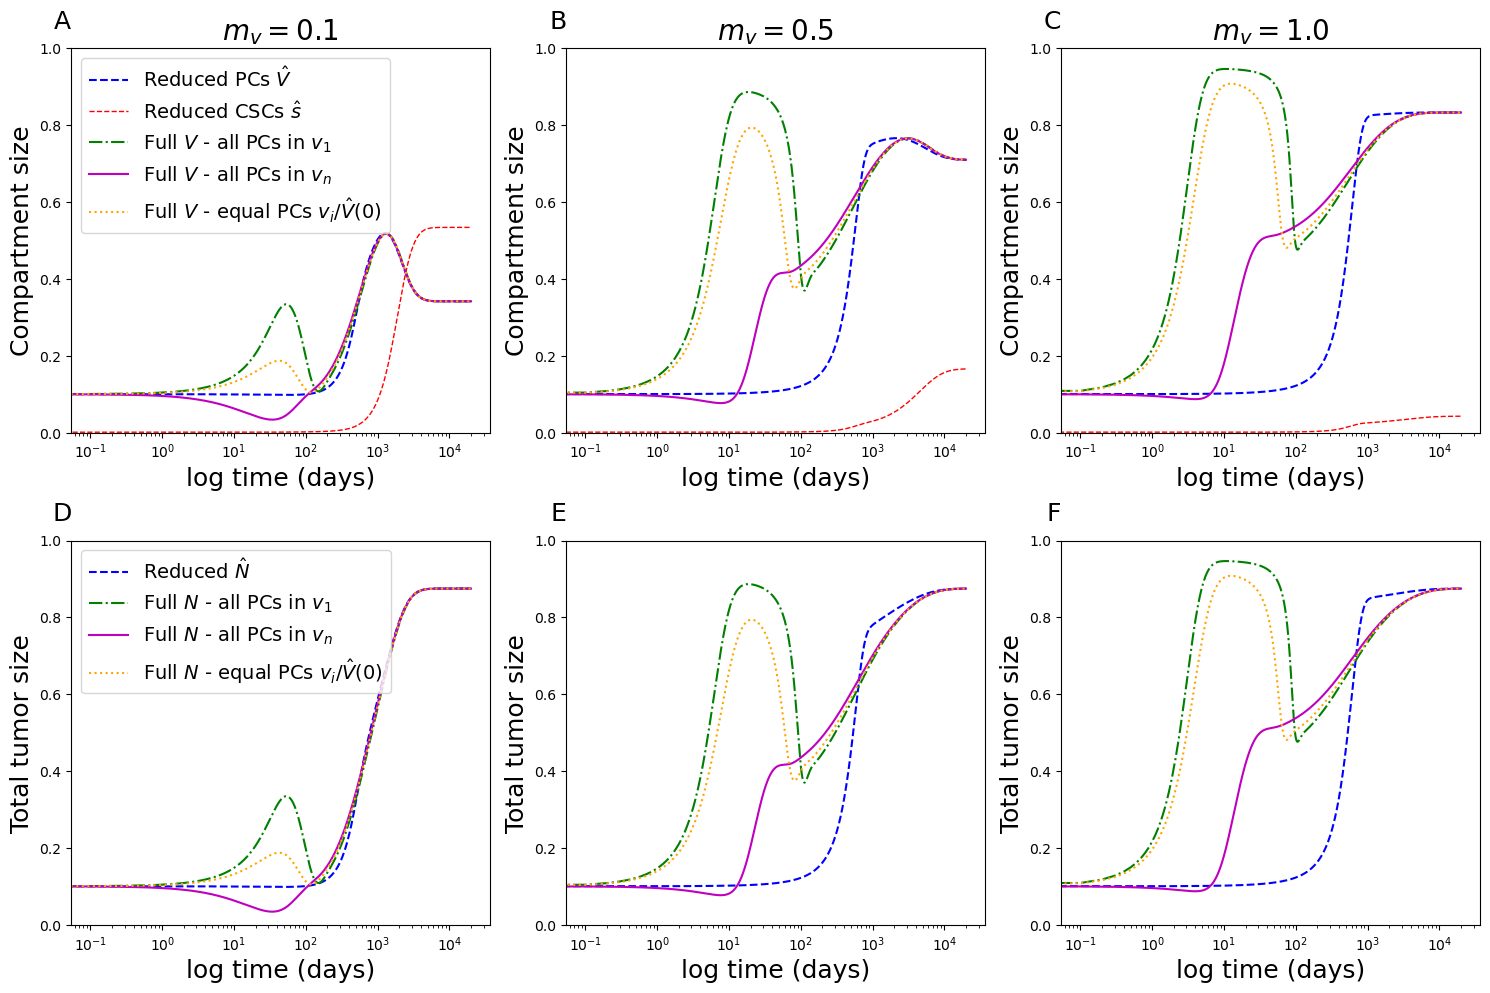

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()

for i in range(3):
    # Top row: PCs ONLY
    ax[i].plot(t, u_red_save[:, :, i][:, 1], linestyle='dashed', color='blue', label='Reduced V')
    # Show CSCs as thin dotted line
    ax[i].plot(t, u_red_save[:, :, i][:, 0], linestyle='dashed', color='red', linewidth=1, label='CSCs')
    ax[i].plot(t, u_full_red_v1_save[:, :, i][:, 1], color='g', label='Full v1', linestyle = '-.')
    ax[i].plot(t, u_full_red_vn_save[:, :, i][:, 1], color='m', label='Full vn', linestyle = '-')
    ax[i].plot(t, u_full_red_equal_save[:, :, i][:, 1], color='orange', label='Full equal', linestyle = ':')

    
    
    ax[i].set_xscale('log')
    ax[i].set_title(f'$m_v = {m_v_vals[i]}$', fontsize=20)
    ax[i].set_xlabel('log time (days)', fontsize=18)
    ax[i].set_ylabel('Compartment size', fontsize=18)
    ax[i].set_ylim(0,1)

for i in range(3):
    idx = i
    # Bottom row: Total = CSCs + PCs with decomposition
    # Reduced total
    reduced_total = np.sum(u_red_save[:, :, idx], axis=1)
    ax[3+i].plot(t, reduced_total, linestyle='dashed', color='blue', label='Reduced Total')
    
    # Full totals
    full_v1_total = np.sum(u_full_red_v1_save[:, :, idx], axis=1)
    full_vn_total = np.sum(u_full_red_vn_save[:, :, idx], axis=1)
    full_equal_total = np.sum(u_full_red_equal_save[:, :, idx], axis=1)
    
    ax[3+i].plot(t, full_v1_total, color='g', label='Full v1', linestyle = '-.')
    ax[3+i].plot(t, full_vn_total, color='m', label='Full vn', linestyle = '-')
    ax[3+i].plot(t, full_equal_total, color='orange', label='Full equal', linestyle = ':')

    # Show CSCs as thin dotted line
    #ax[3+i].plot(t, u_red_save[:, :, idx][:, 0], linestyle=':', color='red', linewidth=1, label='CSCs')
    
    ax[3+i].set_xscale('log')
    #ax[3+i].set_title(f'$m_i = {m_v_vals[i]}$ (Total = CSCs + PCs)', fontsize=18)
    ax[3+i].set_xlabel('log time (days)', fontsize=18)
    ax[3+i].set_ylabel('Total tumor size', fontsize=18)
    ax[3+i].set_ylim(0,1)


for i in range(len(ax)):
    ax[i].text(0, 1.1, chr(65+i), transform=ax[i].transAxes, fontsize=18, va='top', ha='right')

ax[0].legend(['Reduced PCs $\\hat{V}$','Reduced CSCs $\\hat{s}$', 'Full $V$ - all PCs in $v_1$', 'Full $V$ - all PCs in $v_n$', 'Full $V$ - equal PCs $v_i/\\hat{V}(0)$'], fontsize=14, loc  = 'upper left')
ax[3].legend(['Reduced $\\hat{N}$', 'Full $N$ - all PCs in $v_1$', 'Full $N$ - all PCs in $v_n$', 'Full $N$ - equal PCs $v_i/\\hat{V}(0)$'], fontsize = 14, loc = 'upper left')

plt.tight_layout()
plt.savefig('Figs/Full_red_comparison_different_ICs.pdf', bbox_inches='tight')
plt.show()